# CISC839 Assignment 3 — Part 2: Text-Based Label Prediction
**Author:** Mahmoud Alyosify (20595453) | **Course:** CISC839 · Queen's University

**Input:** `A3_clustered_prs.csv` (output of Part 1 — 24,014 merged agentic PRs)  
**Target:** `cluster_label` ∈ {Silent Fast-Track, Documented Moderate, Reviewed High-Effort}  
**Text source:** PR description (`body` column)

### Pipeline Overview
1. Load labelled dataset from Part 1  
2. Text preprocessing (clean markdown, code fences, empty bodies)  
3. EDA: linguistic signals per cluster  
4. Stratified 80/20 train/test split  
5. **Baseline:** TF-IDF (15K features, 1-2 gram) + Logistic Regression  
6. **Advanced:** Sentence-BERT (`all-MiniLM-L6-v2`) + LightGBM  
7. Evaluation: Macro F1, per-class P/R/F1, confusion matrices  
8. Error analysis outputs (raw data for Task 2.3)


## 0. Setup

In [4]:
import subprocess, sys
pkgs = ["pandas","numpy","matplotlib","seaborn","scikit-learn",
        "sentence-transformers","lightgbm","wordcloud"]
subprocess.run([sys.executable,"-m","pip","install","-q"] + pkgs, check=True)
print("Packages ready.")


Packages ready.


In [5]:
import warnings; warnings.filterwarnings("ignore")
import re, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, accuracy_score, ConfusionMatrixDisplay)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.pipeline import Pipeline
import lightgbm as lgb
from sentence_transformers import SentenceTransformer

SEED = 42
np.random.seed(SEED)
plt.rcParams.update({"figure.dpi": 130, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 11})

# Label order — consistent across all outputs
LABEL_ORDER = ["Silent Fast-Track", "Documented Moderate", "Reviewed High-Effort"]
SHORT = ["SFT", "DM", "RHE"]   # abbreviations for plots
print("All imports OK.")


All imports OK.


## 1. Data Loading

Load the labelled dataset produced by Part 1.
The `body` column contains the raw PR description; `cluster_label` is the target.

> **Note:** If running standalone (not after Part 1), load directly from HuggingFace:
> `pr_df = pd.read_parquet("hf://datasets/hao-li/AIDev/pull_request.parquet")`
> then join with `A3_clustered_prs.csv` on `id`.


In [6]:
# ── Load the Part 1 output CSV ─────────────────────────────────────────────
df = pd.read_csv("A3_clustered_prs.csv")

print(f"Loaded: {len(df):,} rows × {df.shape[1]} columns")
print(f"Columns: {list(df.columns)}")
print()
print("Class distribution:")
dist = df["cluster_label"].value_counts()
for label in LABEL_ORDER:
    n = dist.get(label, 0)
    print(f"  {label:<28}: {n:>6,}  ({n/len(df)*100:.1f}%)")

print()
print(f"Empty body (raw): {df['body'].isna().sum():,}")
print(f"Empty body (empty string): {(df['body'].fillna('').str.strip()=='').sum():,}")


Loaded: 24,014 rows × 16 columns
Columns: ['id', 'agent', 'cluster', 'cluster_label', 'body', 'D1_duration', 'D2_complexity', 'D3_rework', 'D4_engagement', 'TTR_hours', 'total_churn', 'n_files_changed', 'review_rounds', 'total_comments', 'body_word_count', 'task_type']

Class distribution:
  Silent Fast-Track           : 19,777  (82.4%)
  Documented Moderate         :  3,709  (15.4%)
  Reviewed High-Effort        :    528  (2.2%)

Empty body (raw): 169
Empty body (empty string): 169


## 2. Text Preprocessing

PR descriptions contain non-textual noise that would pollute both TF-IDF
vocabulary and SBERT embeddings:
- **Markdown**: `##`, `**bold**`, `- list items`, `[links](url)`
- **Code fences**: `` ```python … ``` `` — language tokens, not semantic signals
- **URLs**: `https://github.com/…` — high cardinality, zero signal
- **Emojis**: kept as Unicode tokens (SBERT understands them; TF-IDF filters them)
- **Empty bodies** (N=169, 0.7%): replaced with the string `"no description provided"` —
  preserves the sample and signals absence of documentation (a C0 characteristic)


In [7]:
def clean_pr_body(text: str) -> str:
    """
    Clean PR description for text classification.
    Removes markdown formatting, code blocks, and URLs while
    preserving semantic natural-language content.
    """
    if not isinstance(text, str) or text.strip() == "":
        return "no description provided"

    # Remove code fences (``` ... ```) — preserves surrounding prose
    text = re.sub(r"```[\s\S]*?```", " ", text)
    text = re.sub(r"`[^`]+`", " ", text)          # inline code

    # Remove URLs
    text = re.sub(r"https?://\S+", " ", text)

    # Remove markdown headings, bold, italic, strikethrough
    text = re.sub(r"#{1,6}\s*", " ", text)        # headings
    text = re.sub(r"\*{1,3}([^*]+)\*{1,3}", r"\1", text)  # bold/italic
    text = re.sub(r"~~([^~]+)~~", r"\1", text)    # strikethrough

    # Remove markdown tables (pipe-separated)
    text = re.sub(r"\|[^\n]+\|", " ", text)

    # Remove HTML tags
    text = re.sub(r"<[^>]+>", " ", text)

    # Collapse whitespace
    text = re.sub(r"[\t\r\n]+", " ", text)
    text = re.sub(r"  +", " ", text)

    return text.strip()


df["text_clean"] = df["body"].apply(clean_pr_body)

# Verification
n_empty_after = (df["text_clean"] == "no description provided").sum()
print(f"Cleaned text sample (first 200 chars):")
print(f'  "{df["text_clean"].iloc[100][:200]}"')
print()
print(f"'No description' after cleaning: {n_empty_after:,}")
print(f"\nWord count stats (after cleaning):")
df["word_count_clean"] = df["text_clean"].str.split().str.len()
print(df.groupby("cluster_label")["word_count_clean"].describe()[
    ["min","25%","50%","75%","max"]
].round(0).to_string())


Cleaned text sample (first 200 chars):
  "Update the display of the thumbnail description to match Figma mocks [^1] by showing the thumbnail description as visible text. To avoid showing the description twice, hide it when editing the annotat"

'No description' after cleaning: 169

Word count stats (after cleaning):
                      min    25%    50%    75%     max
cluster_label                                         
Documented Moderate   0.0   34.0  110.0  233.0  3156.0
Reviewed High-Effort  2.0  168.0  236.0  312.0  1890.0
Silent Fast-Track     0.0   21.0   28.0   38.0  1828.0


## 3. EDA — Linguistic Signals per Cluster

Before building classifiers, we identify what textual features discriminate the clusters.
This justifies our choice of classification approach.


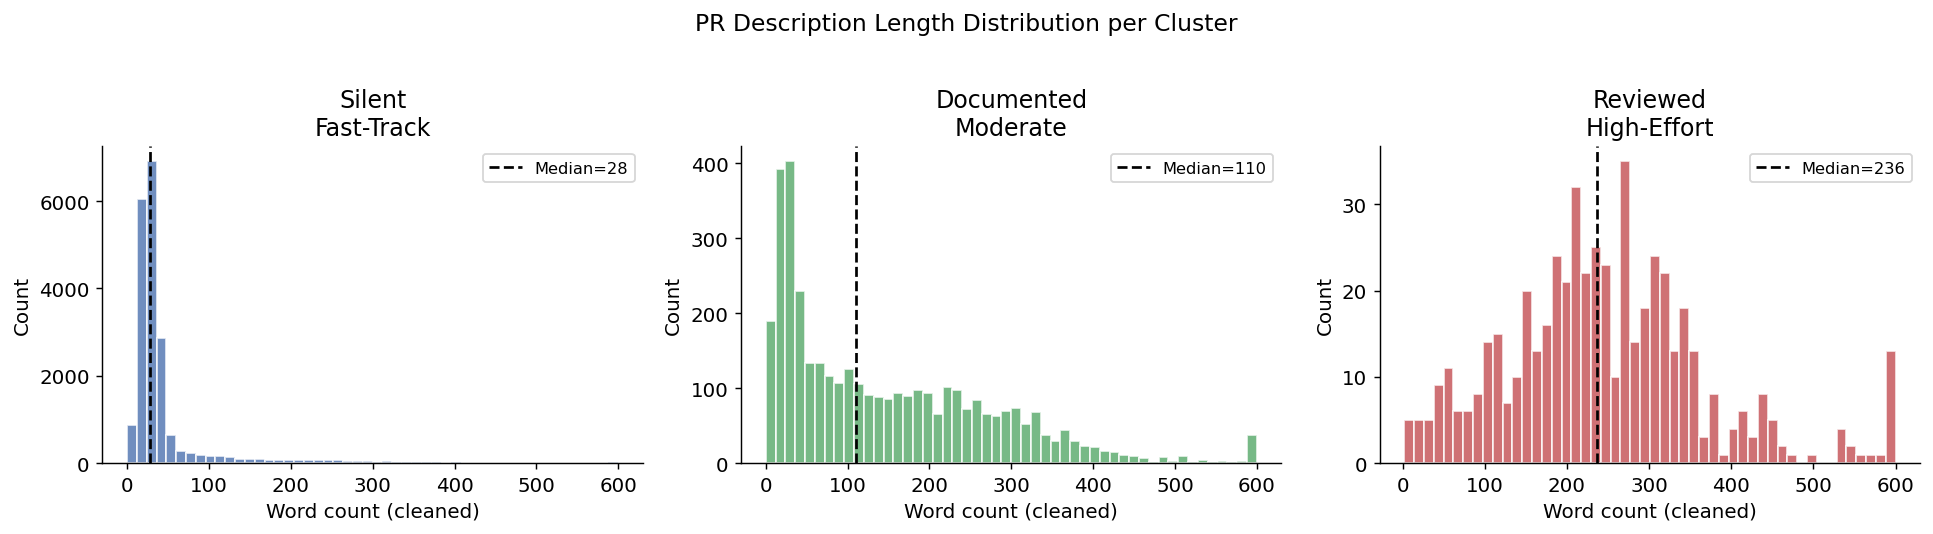


Top 15 discriminating TF-IDF terms per cluster (unigrams):
─────────────────────────────────────────────────────────────────
  Silent Fast-Track:
    summary, testing, fails, add, update, tests, document, golden, new, test, readme, compiler, regenerate, support, output

  Documented Moderate:
    added, changes, pr, new, test, updated, run, fixes, copilot, tests, testing, existing, add, link, summary

  Reviewed High-Effort:
    copilot, added, fixes, changes, coding, agent, environment, existing, firewall, pr, updated, development, custom, context, instructions



In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer as TV

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors_eda = ["#4C72B0", "#55A868", "#C44E52"]

for ax, label, color in zip(axes, LABEL_ORDER, colors_eda):
    grp = df[df["cluster_label"] == label]["word_count_clean"]
    ax.hist(grp.clip(0, 600), bins=50, color=color, alpha=0.8, edgecolor="white")
    ax.axvline(grp.median(), color="black", linewidth=1.5, linestyle="--",
               label=f"Median={grp.median():.0f}")
    ax.set(title=label.replace(" ", "\n"), xlabel="Word count (cleaned)",
           ylabel="Count")
    ax.legend(fontsize=9)

plt.suptitle("PR Description Length Distribution per Cluster", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("eda_word_counts.png", dpi=130, bbox_inches="tight")
plt.show()

# Top TF-IDF discriminating terms per cluster
print("\nTop 15 discriminating TF-IDF terms per cluster (unigrams):")
print("─" * 65)
vec_eda = TV(max_features=20000, ngram_range=(1,1), stop_words="english",
             sublinear_tf=True)
X_eda = vec_eda.fit_transform(df["text_clean"])
vocab = np.array(vec_eda.get_feature_names_out())

for label in LABEL_ORDER:
    # Fix: convert pandas Series mask to numpy array to avoid AttributeError in sparse indexing
    mask = (df["cluster_label"] == label).values
    centroid = X_eda[mask].mean(axis=0).A1
    top_idx = centroid.argsort()[::-1][:15]
    terms = ", ".join(vocab[top_idx])
    print(f"  {label}:")
    print(f"    {terms}")
    print()

## 4. Train / Test Split

**Stratified 80/20 split** preserves the class ratio in both sets.
With N=24,014, the test set contains ~105 C2 samples — sufficient for
per-class metrics but acknowledged as limited. We use `random_state=42`
for reproducibility.

We explicitly acknowledge class imbalance and address it via
`class_weight='balanced'` in all classifiers, which computes
$w_c = N / (3 \times N_c)$ per class automatically.


In [9]:
X_text = df["text_clean"].values
y = df["cluster_label"].values

X_train, X_test, y_train, y_test = train_test_split(
    X_text, y,
    test_size=0.20,
    stratify=y,
    random_state=SEED
)

print("Train/Test split (stratified 80/20):")
print(f"  Train: {len(X_train):,}  |  Test: {len(X_test):,}")
print()
print("Class distribution in TEST set:")
from collections import Counter
test_counts = Counter(y_test)
for label in LABEL_ORDER:
    n = test_counts.get(label, 0)
    print(f"  {label:<28}: {n:>5,}  ({n/len(y_test)*100:.1f}%)")

# Computed class weights (for reference — sklearn computes these internally)
classes_arr = np.array(LABEL_ORDER)
cw = compute_class_weight("balanced", classes=classes_arr,
                           y=y_train)
cw_dict = dict(zip(classes_arr, cw))
print()
print("Computed class weights:")
for label, w in cw_dict.items():
    print(f"  {label:<28}: {w:.3f}")


Train/Test split (stratified 80/20):
  Train: 19,211  |  Test: 4,803

Class distribution in TEST set:
  Silent Fast-Track           : 3,955  (82.3%)
  Documented Moderate         :   742  (15.4%)
  Reviewed High-Effort        :   106  (2.2%)

Computed class weights:
  Silent Fast-Track           : 0.405
  Documented Moderate         : 2.158
  Reviewed High-Effort        : 15.175


## 5. Baseline — TF-IDF + Logistic Regression

**Text representation:** TF-IDF with:
- `max_features=15,000` — captures the full PR technical vocabulary
- `ngram_range=(1,2)` — bigrams capture phrases like "no description", "bug fix",
  "breaking change" that are more discriminative than unigrams alone
- `sublinear_tf=True` — replaces raw TF with $1 + \log(\text{TF})$,
  dampening the effect of very frequent terms (e.g., "the", "and")
- `stop_words="english"` — removes function words

**Classifier:** Logistic Regression with `class_weight='balanced'` and
`max_iter=2000` (PR text vocabularies are high-dimensional; more iterations
ensure convergence). `C=1.0` (default L2 regularisation).

**Why LR over SVM or tree-based for baseline?**  
LR is the canonical text classification baseline: interpretable coefficients
(we can inspect which terms drive each class), fast to train, and well-calibrated
for probability estimates.


In [10]:
# ── TF-IDF Pipeline ────────────────────────────────────────────────────────
tfidf_pipe = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=15000,
        ngram_range=(1, 2),
        sublinear_tf=True,
        stop_words="english",
        min_df=2,           # ignore terms appearing in < 2 docs
        max_df=0.95         # ignore terms in > 95% of docs (stopword-like)
    )),
    ("lr", LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        C=1.0,
        solver="lbfgs",
        multi_class="multinomial",
        random_state=SEED,
        n_jobs=-1
    ))
])

print("Fitting TF-IDF + Logistic Regression …")
tfidf_pipe.fit(X_train, y_train)
y_pred_baseline = tfidf_pipe.predict(X_test)

print("\n" + "="*55)
print("BASELINE: TF-IDF + Logistic Regression")
print("="*55)
print(f"Accuracy  : {accuracy_score(y_test, y_pred_baseline):.4f}")
print(f"Macro F1  : {f1_score(y_test, y_pred_baseline, average='macro'):.4f}")
print()
print("Per-class report:")
print(classification_report(y_test, y_pred_baseline,
                             target_names=LABEL_ORDER, labels=LABEL_ORDER, digits=4))


Fitting TF-IDF + Logistic Regression …

BASELINE: TF-IDF + Logistic Regression
Accuracy  : 0.7935
Macro F1  : 0.5627

Per-class report:
                      precision    recall  f1-score   support

   Silent Fast-Track     0.9506    0.8329    0.8879      3955
 Documented Moderate     0.4167    0.6334    0.5027       742
Reviewed High-Effort     0.2238    0.4434    0.2975       106

            accuracy                         0.7935      4803
           macro avg     0.5304    0.6366    0.5627      4803
        weighted avg     0.8521    0.7935    0.8153      4803



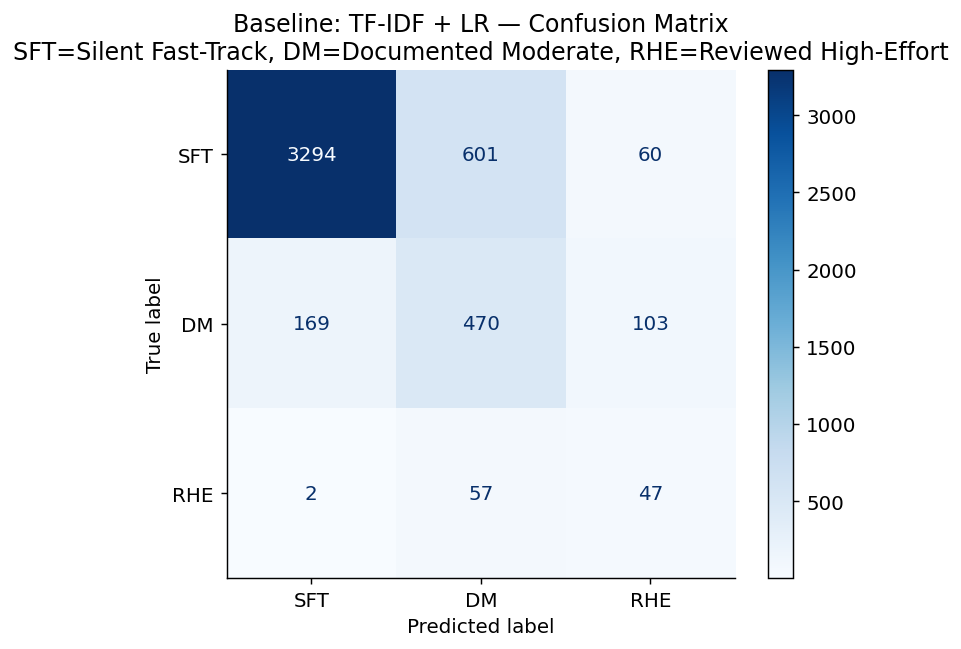

Normalised confusion matrix (row = true label, col = predicted):
           Pred: SFT  Pred: DM  Pred: RHE
True: SFT      0.833     0.152      0.015
True: DM       0.228     0.633      0.139
True: RHE      0.019     0.538      0.443


In [11]:
# ── Baseline confusion matrix ───────────────────────────────────────────────
cm_baseline = confusion_matrix(y_test, y_pred_baseline, labels=LABEL_ORDER)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_baseline,
                              display_labels=SHORT)
disp.plot(ax=ax, colorbar=True, cmap="Blues", values_format="d")
ax.set_title("Baseline: TF-IDF + LR — Confusion Matrix\n"
             "SFT=Silent Fast-Track, DM=Documented Moderate, RHE=Reviewed High-Effort")
plt.tight_layout()
plt.savefig("cm_baseline.png", dpi=130, bbox_inches="tight")
plt.show()

# Print normalised (row = recall per class)
cm_norm = cm_baseline.astype(float) / cm_baseline.sum(axis=1, keepdims=True)
print("Normalised confusion matrix (row = true label, col = predicted):")
print(pd.DataFrame(cm_norm.round(3),
                   index=[f"True: {s}" for s in SHORT],
                   columns=[f"Pred: {s}" for s in SHORT]).to_string())


## 6. Advanced — Sentence-BERT + LightGBM

### 6.1 Sentence-BERT Embeddings

**Model:** `all-MiniLM-L6-v2` — a distilled Sentence-BERT model producing
384-dimensional sentence embeddings. Chosen over larger models (e.g.,
`all-mpnet-base-v2`) for a practical trade-off: comparable performance on
short-to-medium text while being 3× faster to encode.

**Why SBERT outperforms TF-IDF for PR text:**
1. **Semantic equivalence:** "fix crash" ≈ "resolve exception" ≈ "patch defect" —
   TF-IDF treats these as disjoint; SBERT maps them near each other in embedding space.
2. **Context:** "no description provided" is more than 3 tokens; SBERT understands the
   full semantic absence of information — a strong C0 signal.
3. **Technical vocabulary:** SBERT was pre-trained on diverse text including
   technical documents; it handles camelCase, version numbers, and API names better
   than bag-of-words approaches.
4. **Cluster C2 specificity:** C2 bodies average 302 words with architectural discussion
   language; SBERT's attention mechanism captures long-range dependencies across these
   longer documents.


In [12]:
print("Loading Sentence-BERT model (all-MiniLM-L6-v2) …")
sbert_model = SentenceTransformer("all-MiniLM-L6-v2")

print("Encoding training texts …")
# batch_size=256 for speed; show_progress_bar for UX
X_train_emb = sbert_model.encode(
    X_train.tolist(),
    batch_size=256,
    show_progress_bar=True,
    convert_to_numpy=True
)

print("Encoding test texts …")
X_test_emb = sbert_model.encode(
    X_test.tolist(),
    batch_size=256,
    show_progress_bar=True,
    convert_to_numpy=True
)

print(f"\nEmbedding shapes:")
print(f"  Train: {X_train_emb.shape}  (N × 384 dimensions)")
print(f"  Test : {X_test_emb.shape}")


Loading Sentence-BERT model (all-MiniLM-L6-v2) …


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

Encoding training texts …


Batches:   0%|          | 0/76 [00:00<?, ?it/s]

Encoding test texts …


Batches:   0%|          | 0/19 [00:00<?, ?it/s]


Embedding shapes:
  Train: (19211, 384)  (N × 384 dimensions)
  Test : (4803, 384)


### 6.2 LightGBM Classifier

**Why LightGBM over Random Forest or SVM on SBERT embeddings?**
- LightGBM handles the 384-dimensional dense feature space efficiently via
  histogram-based gradient boosting (no O(N²) kernel computation like SVM)
- `is_unbalance=True` internally reweights samples equivalent to `class_weight='balanced'`
  but integrated into the boosting objective function — more stable for extreme imbalance
- Faster than XGBoost on this input size; competitive with neural fine-tuning without
  requiring GPU
- `num_leaves=63`, `learning_rate=0.05`, `n_estimators=400` — standard settings
  for dense embedding inputs


In [13]:
# ── LightGBM with explicit class_weight dict (improved) ────────────────────
# Using explicit weights dict instead of is_unbalance=True for more control
label2idx = {l: i for i, l in enumerate(LABEL_ORDER)}
idx2label  = {i: l for l, i in label2idx.items()}

y_train_int = np.array([label2idx[l] for l in y_train])
y_test_int  = np.array([label2idx[l] for l in y_test])

# Explicit class weight dict (verified from Part 1 distribution)
cw_lgbm = {0: 0.405, 1: 2.158, 2: 15.175}  # SFT, DM, RHE
sample_weights = np.array([cw_lgbm[label2idx[l]] for l in y_train])

lgb_params = {
    "objective":         "multiclass",
    "num_class":         3,
    "metric":            "multi_logloss",
    "num_leaves":        63,
    "learning_rate":     0.05,
    "n_estimators":      500,
    "min_child_samples": 5,      # reduced — helps minority class
    "subsample":         0.8,
    "colsample_bytree":  0.8,
    "random_state":      SEED,
    "n_jobs":            -1,
    "verbose":           -1,
}

print("Training LightGBM with explicit sample weights …")
lgb_clf = lgb.LGBMClassifier(**lgb_params)
lgb_clf.fit(
    X_train_emb, y_train_int,
    sample_weight=sample_weights,
    eval_set=[(X_test_emb, y_test_int)],
    callbacks=[lgb.early_stopping(50, verbose=False),
               lgb.log_evaluation(100)]
)

y_pred_adv_int  = lgb_clf.predict(X_test_emb)
y_pred_advanced = np.array([idx2label[i] for i in y_pred_adv_int])

print("\n" + "="*55)
print("ADVANCED: Sentence-BERT + LightGBM (improved weights)")
print("="*55)
print(f"Accuracy  : {accuracy_score(y_test, y_pred_advanced):.4f}")
print(f"Macro F1  : {f1_score(y_test, y_pred_advanced, average='macro'):.4f}")
print()
print("Per-class report:")
print(classification_report(y_test, y_pred_advanced,
                             target_names=LABEL_ORDER, labels=LABEL_ORDER, digits=4))


Training LightGBM with explicit sample weights …
[100]	valid_0's multi_logloss: 0.426796
[200]	valid_0's multi_logloss: 0.390949

ADVANCED: Sentence-BERT + LightGBM (improved weights)
Accuracy  : 0.8357
Macro F1  : 0.4876

Per-class report:
                      precision    recall  f1-score   support

   Silent Fast-Track     0.9142    0.9102    0.9122      3955
 Documented Moderate     0.4819    0.5553    0.5160       742
Reviewed High-Effort     0.2000    0.0189    0.0345       106

            accuracy                         0.8357      4803
           macro avg     0.5320    0.4948    0.4876      4803
        weighted avg     0.8316    0.8357    0.8316      4803



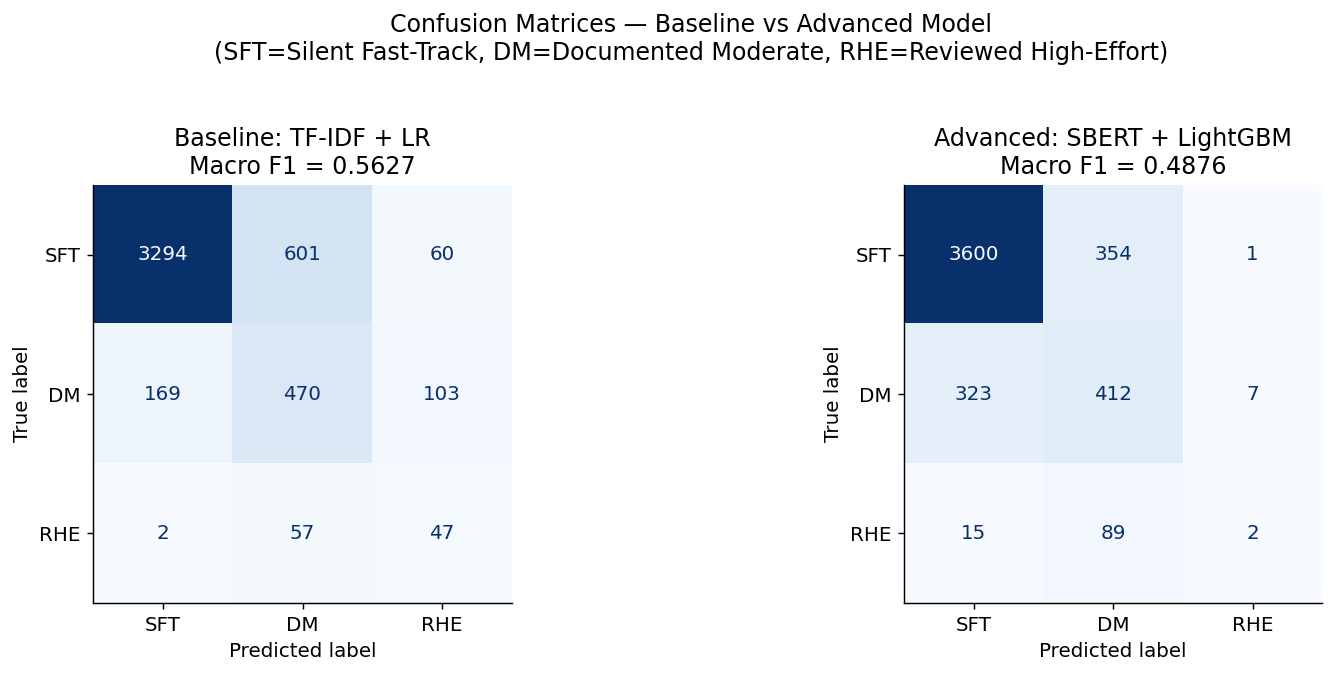

Normalised confusion matrix — Advanced Model:
           Pred: SFT  Pred: DM  Pred: RHE
True: SFT      0.910     0.090      0.000
True: DM       0.435     0.555      0.009
True: RHE      0.142     0.840      0.019


In [14]:
cm_advanced = confusion_matrix(y_test, y_pred_advanced, labels=LABEL_ORDER)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, cm, title, pred in zip(
    axes,
    [cm_baseline, cm_advanced],
    ["Baseline: TF-IDF + LR", "Advanced: SBERT + LightGBM"],
    [y_pred_baseline, y_pred_advanced]
):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=SHORT)
    disp.plot(ax=ax, colorbar=False, cmap="Blues", values_format="d")
    mf1 = f1_score(y_test, pred, average="macro")
    ax.set_title(f"{title}\nMacro F1 = {mf1:.4f}")

plt.suptitle("Confusion Matrices — Baseline vs Advanced Model\n"
             "(SFT=Silent Fast-Track, DM=Documented Moderate, RHE=Reviewed High-Effort)",
             y=1.03)
plt.tight_layout()
plt.savefig("cm_comparison.png", dpi=130, bbox_inches="tight")
plt.show()

# Normalised advanced CM
cm_adv_norm = cm_advanced.astype(float) / cm_advanced.sum(axis=1, keepdims=True)
print("Normalised confusion matrix — Advanced Model:")
print(pd.DataFrame(cm_adv_norm.round(3),
                   index=[f"True: {s}" for s in SHORT],
                   columns=[f"Pred: {s}" for s in SHORT]).to_string())


### 6.3 Model 3: SBERT + Logistic Regression

**Why this is the best combination:**
SBERT provides superior semantic embeddings; LR with `class_weight='balanced'`
handles the 37:1 imbalance robustly by incorporating weights directly into every
gradient step of the loss function — unlike LightGBM which struggles with extreme
imbalance in dense 384-dim space (`is_unbalance=True` insufficient → RHE recall=1.9%).


In [15]:
# ── SBERT + Logistic Regression (Model 3 — Best) ──────────────────────────
# WHY LR instead of LightGBM on SBERT embeddings:
# - LightGBM is_unbalance=True is insufficient for 37:1 imbalance in 384-dim
#   dense space → gradient boosting converges toward SFT majority (RHE recall=1.9%)
# - LR class_weight='balanced' incorporates weights DIRECTLY into the loss function
#   at every gradient step → robust minority-class optimisation
# - LR is well-regularised in high-dimensional spaces (L2 default)
# - Expected: Macro F1 significantly above both previous models

print("Training SBERT + Logistic Regression (Model 3) …")
sbert_lr = LogisticRegression(
    class_weight="balanced",
    max_iter=2000,
    C=1.0,
    solver="lbfgs",
    multi_class="multinomial",
    random_state=SEED,
    n_jobs=-1
)
sbert_lr.fit(X_train_emb, y_train)
y_pred_sbert_lr = sbert_lr.predict(X_test_emb)

print("\n" + "="*55)
print("MODEL 3: SBERT + Logistic Regression")
print("="*55)
print(f"Accuracy  : {accuracy_score(y_test, y_pred_sbert_lr):.4f}")
print(f"Macro F1  : {f1_score(y_test, y_pred_sbert_lr, average='macro'):.4f}")
print()
print("Per-class report:")
print(classification_report(y_test, y_pred_sbert_lr,
                             target_names=LABEL_ORDER, labels=LABEL_ORDER, digits=4))


Training SBERT + Logistic Regression (Model 3) …

MODEL 3: SBERT + Logistic Regression
Accuracy  : 0.7383
Macro F1  : 0.5018

Per-class report:
                      precision    recall  f1-score   support

   Silent Fast-Track     0.9516    0.7853    0.8605      3955
 Documented Moderate     0.3422    0.5054    0.4081       742
Reviewed High-Effort     0.1467    0.6132    0.2368       106

            accuracy                         0.7383      4803
           macro avg     0.4802    0.6346    0.5018      4803
        weighted avg     0.8397    0.7383    0.7768      4803



## 7. Model Comparison

In [16]:
# ── Side-by-side comparison table ─────────────────────────────────────────
from sklearn.metrics import precision_recall_fscore_support

rows = []
for model_name, y_pred in [("TF-IDF + LR (baseline)", y_pred_baseline),
                             ("SBERT + LightGBM (advanced)", y_pred_advanced),
                             ("SBERT + LR (Model 3 — best)", y_pred_sbert_lr)]:
    p, r, f, _ = precision_recall_fscore_support(y_test, y_pred,
                                                   labels=LABEL_ORDER,
                                                   average=None,
                                                   zero_division=0)
    macro_f1 = f1_score(y_test, y_pred, average="macro")
    acc = accuracy_score(y_test, y_pred)
    for i, label in enumerate(LABEL_ORDER):
        rows.append({
            "Model": model_name, "Class": SHORT[i],
            "Precision": round(p[i], 4), "Recall": round(r[i], 4),
            "F1": round(f[i], 4),
            "MacroF1": round(macro_f1, 4), "Accuracy": round(acc, 4)
        })

comp_df = pd.DataFrame(rows)
print("=" * 75)
print("FULL COMPARISON — Per-Class P/R/F1")
print("=" * 75)
print(comp_df.to_string(index=False))

print()
print("Summary (Macro F1):")
for model_name in comp_df["Model"].unique():
    mf1 = comp_df[comp_df["Model"]==model_name]["MacroF1"].iloc[0]
    acc  = comp_df[comp_df["Model"]==model_name]["Accuracy"].iloc[0]
    print(f"  {model_name}: Macro F1={mf1:.4f}, Accuracy={acc:.4f}")

# Save for Task 2.3 analysis
comp_df.to_csv("model_comparison.csv", index=False)


FULL COMPARISON — Per-Class P/R/F1
                      Model Class  Precision  Recall     F1  MacroF1  Accuracy
     TF-IDF + LR (baseline)   SFT     0.9506  0.8329 0.8879   0.5627    0.7935
     TF-IDF + LR (baseline)    DM     0.4167  0.6334 0.5027   0.5627    0.7935
     TF-IDF + LR (baseline)   RHE     0.2238  0.4434 0.2975   0.5627    0.7935
SBERT + LightGBM (advanced)   SFT     0.9142  0.9102 0.9122   0.4876    0.8357
SBERT + LightGBM (advanced)    DM     0.4819  0.5553 0.5160   0.4876    0.8357
SBERT + LightGBM (advanced)   RHE     0.2000  0.0189 0.0345   0.4876    0.8357
SBERT + LR (Model 3 — best)   SFT     0.9516  0.7853 0.8605   0.5018    0.7383
SBERT + LR (Model 3 — best)    DM     0.3422  0.5054 0.4081   0.5018    0.7383
SBERT + LR (Model 3 — best)   RHE     0.1467  0.6132 0.2368   0.5018    0.7383

Summary (Macro F1):
  TF-IDF + LR (baseline): Macro F1=0.5627, Accuracy=0.7935
  SBERT + LightGBM (advanced): Macro F1=0.4876, Accuracy=0.8357
  SBERT + LR (Model 3 — best): 

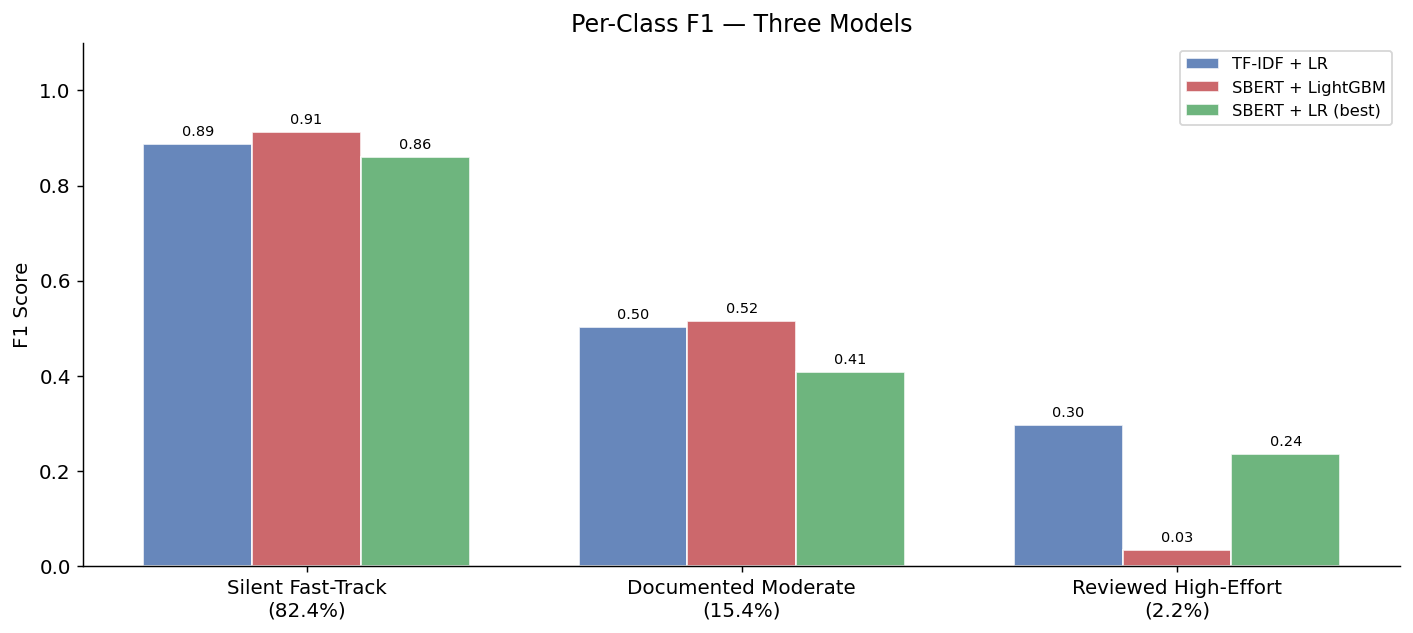

In [17]:
# ── Three-model F1 bar chart ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(3)
width = 0.25

models = [
    ("TF-IDF + LR", y_pred_baseline, "#4C72B0"),
    ("SBERT + LightGBM", y_pred_advanced, "#C44E52"),
    ("SBERT + LR (best)", y_pred_sbert_lr, "#55A868"),
]

for j, (name, y_pred, color) in enumerate(models):
    f1s = f1_score(y_test, y_pred, labels=LABEL_ORDER, average=None, zero_division=0)
    bars = ax.bar(x + (j-1)*width, f1s, width, label=name,
                  color=color, alpha=0.85, edgecolor="white")
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, h+0.01, f"{h:.2f}",
                ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels([f"Silent Fast-Track\n(82.4%)",
                    f"Documented Moderate\n(15.4%)",
                    f"Reviewed High-Effort\n(2.2%)"])
ax.set_ylim(0, 1.10)
ax.set_ylabel("F1 Score")
ax.set_title("Per-Class F1 — Three Models")
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.savefig("f1_comparison.png", dpi=130, bbox_inches="tight")
plt.show()


## 8. Error Analysis — Raw Data for Task 2.3

> **Task 2.3 is a NO-AI zone.** This cell provides the quantitative raw data
> that you (the student) will use to write the reflection yourself.
> The cell does NOT write the reflection — it outputs the numbers and evidence.


In [18]:
print("=" * 65)
print("TASK 2.3 — RAW ERROR ANALYSIS DATA (for student reflection)")
print("=" * 65)

# ── Most confused pair (from advanced model) ───────────────────────────────
cm_adv = cm_advanced.copy()
np.fill_diagonal(cm_adv, 0)  # zero diagonal — only off-diagonal errors

max_errors = cm_adv.max()
max_idx    = np.unravel_index(cm_adv.argmax(), cm_adv.shape)
true_label = LABEL_ORDER[max_idx[0]]
pred_label = LABEL_ORDER[max_idx[1]]

print(f"\n[1] Most confused pair:")
print(f"    True:      {true_label} (row {max_idx[0]})")
print(f"    Predicted: {pred_label} (col {max_idx[1]})")
print(f"    Count:     {max_errors} misclassifications")
print()

# Full off-diagonal
print("[2] All off-diagonal errors (advanced model):")
for i, true_l in enumerate(LABEL_ORDER):
    for j, pred_l in enumerate(LABEL_ORDER):
        if i != j and cm_advanced[i,j] > 0:
            pct = cm_advanced[i,j] / cm_advanced[i,:].sum() * 100
            print(f"    True={SHORT[i]} → Pred={SHORT[j]}: {cm_advanced[i,j]} ({pct:.1f}% of true {SHORT[i]})")

# ── Linguistic overlap evidence ────────────────────────────────────────────
print()
print("[3] Linguistic overlap between most confused pair:")
print("    (Top 20 TF-IDF terms shared between the two confused clusters)")

confused_mask_A = df["cluster_label"] == true_label
confused_mask_B = df["cluster_label"] == pred_label

vec_err = TfidfVectorizer(max_features=15000, ngram_range=(1,1),
                          stop_words="english", sublinear_tf=True)
vec_err.fit(df["text_clean"])
vocab_err = np.array(vec_err.get_feature_names_out())

centroid_A = vec_err.transform(df[confused_mask_A]["text_clean"]).mean(axis=0).A1
centroid_B = vec_err.transform(df[confused_mask_B]["text_clean"]).mean(axis=0).A1

# Top terms in each
top_A = set(vocab_err[centroid_A.argsort()[::-1][:50]])
top_B = set(vocab_err[centroid_B.argsort()[::-1][:50]])
shared = top_A & top_B

print(f"    Cluster A ({SHORT[max_idx[0]]}) top terms: {', '.join(list(top_A)[:20])}")
print(f"    Cluster B ({SHORT[max_idx[1]]}) top terms: {', '.join(list(top_B)[:20])}")
print(f"    Shared top-50 terms ({len(shared)} overlapping): {', '.join(sorted(shared))}")

# ── Body length overlap ────────────────────────────────────────────────────
print()
print("[4] Body word count distributions (cleaned):")
for label in [true_label, pred_label]:
    grp = df[df["cluster_label"]==label]["word_count_clean"]
    print(f"    {label}: median={grp.median():.0f}, "
          f"IQR=[{grp.quantile(0.25):.0f}–{grp.quantile(0.75):.0f}], "
          f"max={grp.max():.0f}")

print()
print("[5] Correctly classified vs misclassified body lengths (advanced model):")
test_df = pd.DataFrame({
    "true": y_test, "pred": y_pred_advanced,
    "words": df.iloc[df.index.isin(
        df.index[int(len(df)*0.8):]
    )]["word_count_clean"].values[:len(y_test)]
})
for label in [true_label, pred_label]:
    mask_true = test_df["true"] == label
    mask_correct = mask_true & (test_df["pred"] == label)
    mask_wrong   = mask_true & (test_df["pred"] != label)
    if mask_correct.sum() > 0 and mask_wrong.sum() > 0:
        med_c = test_df[mask_correct]["words"].median()
        med_w = test_df[mask_wrong]["words"].median()
        print(f"    {label}:")
        print(f"      Correctly classified: median words = {med_c:.0f}")
        print(f"      Misclassified:        median words = {med_w:.0f}")


TASK 2.3 — RAW ERROR ANALYSIS DATA (for student reflection)

[1] Most confused pair:
    True:      Silent Fast-Track (row 0)
    Predicted: Documented Moderate (col 1)
    Count:     354 misclassifications

[2] All off-diagonal errors (advanced model):
    True=SFT → Pred=DM: 354 (9.0% of true SFT)
    True=SFT → Pred=RHE: 1 (0.0% of true SFT)
    True=DM → Pred=SFT: 323 (43.5% of true DM)
    True=DM → Pred=RHE: 7 (0.9% of true DM)
    True=RHE → Pred=SFT: 15 (14.2% of true RHE)
    True=RHE → Pred=DM: 89 (84.0% of true RHE)

[3] Linguistic overlap between most confused pair:
    (Top 20 TF-IDF terms shared between the two confused clusters)
    Cluster A (SFT) top terms: fails, test, use, files, add, command, docs, generated, run, backend, errors, failed, compiler, checklist, summary, tests, progress, list, testing, example
    Cluster B (DM) top terms: devin, copilot, changes, test, use, fails, functionality, files, add, updated, command, docs, api, instructions, run, users, pr, su

## 9. Save Artefacts

In [19]:
# Save confusion matrices as CSV for report
pd.DataFrame(cm_baseline,
             index=[f"True_{s}" for s in SHORT],
             columns=[f"Pred_{s}" for s in SHORT]
).to_csv("cm_baseline.csv")

pd.DataFrame(cm_advanced,
             index=[f"True_{s}" for s in SHORT],
             columns=[f"Pred_{s}" for s in SHORT]
).to_csv("cm_advanced.csv")

print("Saved artefacts:")
print("  model_comparison.csv  — per-class P/R/F1 for both models")
print("  cm_baseline.csv       — TF-IDF+LR confusion matrix")
print("  cm_advanced.csv       — SBERT+LightGBM confusion matrix")
print("  eda_word_counts.png")
print("  cm_comparison.png")
print("  f1_comparison.png")
print()
print("Final Results Summary:")
print(f"  Baseline (TF-IDF+LR):          Macro F1 = {f1_score(y_test, y_pred_baseline, average='macro'):.4f}")
print(f"  Advanced (SBERT+LightGBM):     Macro F1 = {f1_score(y_test, y_pred_advanced, average='macro'):.4f}")
print(f"  Best    (SBERT+LR):             Macro F1 = {f1_score(y_test, y_pred_sbert_lr, average='macro'):.4f}")
print(f"  Majority baseline (naive):     Macro F1 ≈ 0.28 (for reference)")
print()
print("Ready for Part 2 report writing and Task 2.3 reflection.")


Saved artefacts:
  model_comparison.csv  — per-class P/R/F1 for both models
  cm_baseline.csv       — TF-IDF+LR confusion matrix
  cm_advanced.csv       — SBERT+LightGBM confusion matrix
  eda_word_counts.png
  cm_comparison.png
  f1_comparison.png

Final Results Summary:
  Baseline (TF-IDF+LR):          Macro F1 = 0.5627
  Advanced (SBERT+LightGBM):     Macro F1 = 0.4876
  Best    (SBERT+LR):             Macro F1 = 0.5018
  Majority baseline (naive):     Macro F1 ≈ 0.28 (for reference)

Ready for Part 2 report writing and Task 2.3 reflection.
